In [1]:
# ---- 1-1 Libraries for Path and Logging ----
import os
import sys
import typer
from tqdm import tqdm
from pathlib import Path
from loguru import logger
# 获取当前 Jupyter Notebook 文件所在的目录
current_dir = Path.cwd()

# 获取当前目录的上级目录的上级目录
ADDR_ROOT = current_dir.parent.parent

# 设置代码目录路径
ADDR_CODE = ADDR_ROOT / "codes"

sys.path.append(str(ADDR_ROOT))
sys.path.append(str(ADDR_CODE))

logger.success(f"ADDR_ROOT set to: {ADDR_ROOT}")
logger.success(f"ADDR_CODE  set to: {ADDR_CODE}")

# ---- 1-2 Libraries for Configuration and Modules ----
from codes.function.Log import log
import codes.function.Train as Train
import codes.function.Loss as lossfunction
from codes.config.config_DDPM import EvalConfig
from codes.config.config_DDPM import ModelConfig
from codes.function.Dataset import ImageDataset, DataModule, SingleImageDataset
# ---- 1-3 PyTorch ----
import torch
import torch.cuda
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader,random_split, ConcatDataset
# ---- 1-4 Others ----
import scipy
import importlib
import numpy as np
import seaborn as sns
from datetime import datetime
import matplotlib.pyplot as plt

import deeplay as dl
# ---- 1-5 eval ----
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from torchmetrics.image import MultiScaleStructuralSimilarityIndexMeasure as MS_SSIM
from torchmetrics.image import StructuralSimilarityIndexMeasure as SSIM
from torchmetrics.image import PeakSignalNoiseRatio as PSNR
from torchmetrics.regression import MeanAbsoluteError as MAE

2026-03-23 12:53:14.859 | SUCCESS  | __main__:<module>:20 - ADDR_ROOT set to: /root/LHAI
2026-03-23 12:53:14.860 | SUCCESS  | __main__:<module>:21 - ADDR_CODE  set to: /root/LHAI/codes

libgomp: Invalid value for environment variable OMP_NUM_THREADS
/root/miniconda3/envs/LHAI/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ---- 0. 配置与设备 ----
eval_cfg = EvalConfig()
model_cfg = ModelConfig()

# 用传参覆盖默认
exp_name = eval_cfg.exp_name
# data_dir = eval_cfg.data_dir
# data_dir = Path("/root/autodl-fs")
model_name_diffusion = 'DDPM'
model_name_unet = "UNET"
model_dir =  eval_cfg.model_dir
seed = eval_cfg.seed
dataname = eval_cfg.dataname

model_path = model_dir / f"{model_name_diffusion}.py"
model_weight_name = "Last_DDPM_EXP01_400epo_256bth_xinyu.pth"
model_weight_dir = Path("/root/LHAI/saves/MODEL/DDPM")
# model_weight_dir = Path("D:/Research$Study/LHAI/LHAI-codes/saves/MODEL/DDPM")
model_weight_path = model_weight_dir / model_weight_name

torch.manual_seed(seed)
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

logger.success("========= 2-1 参数加载完成 =========")

2026-03-23 12:53:18.835 | SUCCESS  | __main__:<module>:25 - ========= 2-1 参数加载完成 =========


cuda:0


In [3]:
# ==== 2-2 Data: trainloader & testloader ====
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import scipy.interpolate

class SinglePairedDataset(Dataset):
    """
    用于单张配对图像推理的数据集。
    输入： path_img -> .npy 文件 (形状: (1, 2, H, W))
           通道 0: 清晰图像 (HR/Target)
           通道 1: 模糊图像 (LR/Input)
    输出： lr_tensor, hr_tensor (形状均为 [1, H, W])
    """
    def __init__(self, path_img, data_range=1.0):
        if not os.path.exists(path_img):
            raise FileNotFoundError(f"{path_img} not found.")

        # 加载数据，shape: (1, 2, H, W)
        img = np.load(path_img).astype(np.float32)

        # 归一化 (保留你的原逻辑)
        if abs(data_range - 1.0) < 1e-5:
            img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        elif abs(data_range - 2.0) < 1e-5:
            img = 2 * (img - img.min()) / (img.max() - img.min() + 1e-8) - 1
        else:
            raise ValueError("data_range must be 1.0 or 2.0")

        # 提取通道并转换为 Tensor
        # img[0, 1] 是模糊图， img[0, 0] 是清晰图
        # 加上 np.newaxis 保持 [1, H, W] 的维度格式
        self.lr_tensor = torch.from_numpy(img[0, 1][np.newaxis, ...])
        self.hr_tensor = torch.from_numpy(img[0, 0][np.newaxis, ...])

    def __len__(self):
        return 1

    def __getitem__(self, index):
        return self.lr_tensor, self.hr_tensor

data_dir = "/root/LHAI/data/Predict"
data_name = 'HESS1_bin0.npy'
data_path = os.path.join(data_dir, data_name)

datarange = 1.0  # 或者根据你的模型设定为 2.0
dataset = SinglePairedDataset(data_path, data_range=datarange)
testloader = DataLoader(dataset, batch_size=1, shuffle=False)

# 获取测试图像
test_input_images, test_target_images = next(iter(testloader))
test_input_images = test_input_images.to(device)
test_target_images = test_target_images.to(device)

logger.success(f"========= 数据加载完成: Input {test_input_images.shape}, Target {test_target_images.shape} =========")

2026-03-23 12:53:18.975 | SUCCESS  | __main__:<module>:58 - ========= 数据加载完成: Input torch.Size([1, 1, 128, 128]), Target torch.Size([1, 1, 128, 128]) =========


In [4]:
print(test_input_images.shape)
print(test_target_images.shape)

img = test_input_images[0][0]

print(test_input_images[0])
print("max:", img.max().item())
print("min:", img.min().item())
print("mean:", img.mean().item())

torch.Size([1, 1, 128, 128])
torch.Size([1, 1, 128, 128])
tensor([[[0.0315, 0.0668, 0.0239,  ..., 0.0242, 0.0169, 0.0111],
         [0.0365, 0.0116, 0.0377,  ..., 0.0132, 0.0276, 0.0168],
         [0.0095, 0.0451, 0.0294,  ..., 0.0288, 0.0122, 0.0496],
         ...,
         [0.0209, 0.0246, 0.0473,  ..., 0.0274, 0.0439, 0.0255],
         [0.0496, 0.0432, 0.0473,  ..., 0.0423, 0.0406, 0.0281],
         [0.0432, 0.0300, 0.0094,  ..., 0.0407, 0.0348, 0.0480]]],
       device='cuda:0')
max: 1.0
min: 0.0
mean: 0.2811041474342346


In [5]:
# ==== 2-3 Initialize the model ====
# DIFFUSION
model_params = model_cfg.model_params
params_diffusion = model_params[model_name_diffusion]
params_unet = model_params[model_name_unet]

sys.path.append(str(model_dir))
module_diffusion = importlib.import_module(model_name_diffusion)
DIFFUSION = getattr(module_diffusion, model_name_diffusion)

diffusion = DIFFUSION(**params_diffusion)

# Unet
model_params = model_cfg.model_params
params_unet = model_params[model_name_unet]
sys.path.append(str(model_dir))
module_unet = importlib.import_module(model_name_unet)
UNET = getattr(module_unet, model_name_unet)

unet = UNET(**params_unet).to(device)
unet.build()
unet.to(device)

# 加载权重
unet.load_state_dict(torch.load(model_weight_path, map_location=device))

# loss
trainingloss = lossfunction.msejsloss

logger.success(f"========= 2-3 模型、模型参数与loss加载完成 =========")

2026-03-23 12:53:19.398 | SUCCESS  | __main__:<module>:30 - ========= 2-3 模型、模型参数与loss加载完成 =========


In [6]:
# ==== 2-4 Evaluation ====

# save path
dataname = data_name.split("_")[0]
save_dir_eval = ADDR_ROOT / "saves" / "EVAL" / model_name_diffusion
if not os.path.exists(save_dir_eval):
    os.makedirs(save_dir_eval)

# logger output
format_model_params = Train.format_model_params
torch.set_printoptions(precision=10)
train_time = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No CUDA device"
loss_name = trainingloss.__name__
model_params_str_diffusion = format_model_params(model_params[model_name_diffusion])
model_params_str_unet = format_model_params(model_params[model_name_unet])
filetmp = np.load(data_path, allow_pickle=True)
filelen = int(filetmp.shape[0])
del filetmp
train_msg = f"""
====================== 评估参数 ======================
🔧 配置信息概览：
- traintime               : {train_time}
- exp_name                : {exp_name}
- model_name              : {model_name_diffusion} + {model_name_unet}
- data_name               : {data_name}（{dataname}）
- model_path              : {model_path}
- data_path               : {data_path}
- seed                    : {seed}
- datalength              : {filelen}
- datarange               : {datarange}
- device                  : {device}({gpu_name})
- model_params_diffusion  : 

{model_params_str_diffusion}
- model_params_unet       :

{model_params_str_unet}
==============================================================
"""
logger.info(train_msg)

2026-03-23 12:53:19.406 | INFO     | __main__:<module>:41 - 
====================== 评估参数 ======================
🔧 配置信息概览：
- traintime               : 2026-03-23 12:53:19
- exp_name                : EXP01
- model_name              : DDPM + UNET
- data_name               : HESS1_bin0.npy（HESS1）
- model_path              : /root/LHAI/codes/models/DDPM.py
- data_path               : /root/LHAI/data/Predict/HESS1_bin0.npy
- seed                    : 0
- datalength              : 1
- datarange               : 1.0
- device                  : cuda:0(NVIDIA GeForce RTX 5090)
- model_params_diffusion  : 

        • noise_steps : 2000
        • beta_start  : 1e-06
        • beta_end    : 0.01
        • img_size    : 128
        • device      : None
        • pos_emb_dim : 256
        • conditional : True
- model_params_unet       :

        • jpt                    : None
        • in_channels            : 2
        • channels               : [32, 64, 128]
        • base_channels          : [256,

In [7]:
# ---- 3. 插值函数 ----
def interp2d(x1, x2, y1, y2, arr):
    x = np.arange(arr.shape[0])
    y = np.arange(arr.shape[1])
    interpolate = scipy.interpolate.RegularGridInterpolator((x, y), arr, bounds_error=False, fill_value=None)
    y_t = np.linspace(x1, x2, 101)
    x_t = np.linspace(y1, y2, 101)
    pts = np.column_stack((x_t, y_t))
    z_t = interpolate(pts)
    return z_t

# ---- 4. 执行推理 ----
with torch.no_grad():
    generated_images = diffusion.reverse_diffusion(
        model=unet,
        n_images=1,
        n_channels=1,
        input_image=test_input_images,
        save_time_steps=None
    )

# 转置维度，从 (T, B, C, H, W) → (B, T, C, H, W)
generated_images = generated_images.swapaxes(0, 1)


Sampling: 100%|██████████| 2000/2000 [00:04<00:00, 460.31it/s]


/tmp/ipykernel_2408/2312675757.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
2026-03-23 12:53:23.864 | SUCCESS  | __main__:<module>:50 - ========= 2-4-2 单图 lineprofiles and resmap 评估完成 =========


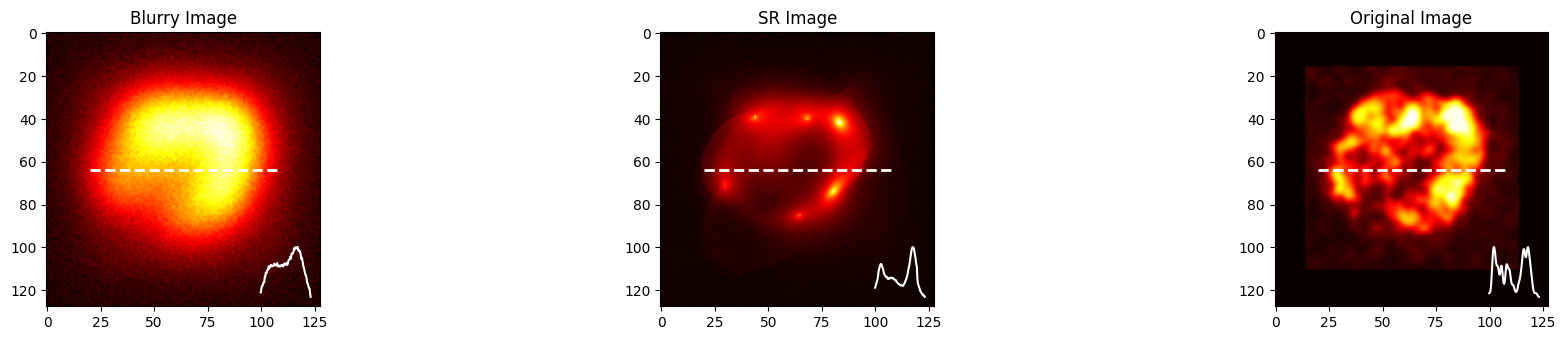

In [8]:
# ---- 5. 提取绘图数据与后处理 ----
img_LR = test_input_images.cpu()
img_HR = test_target_images.cpu()

# 设定剖面线坐标 (针对 128x128 图像，取中间一段)
x1, x2, y1, y2 = 20, 108, 64, 64  
color = 'white'

fig, axes = plt.subplots(1, 3, figsize=(20, 3.5))

# 降维至 2D: (128, 128)
blurry_img_numpy = img_LR.squeeze().numpy()
original_img_numpy = img_HR.squeeze().numpy()
sr_img_numpy = generated_images[0, -1].cpu().squeeze().numpy()

# 归一化（使得积分总面积一致，方便曲线对比）
blurry_img_numpy = blurry_img_numpy / (blurry_img_numpy.sum() + 1e-8)
sr_img_numpy = sr_img_numpy / (sr_img_numpy.sum() + 1e-8)
original_img_numpy = original_img_numpy / (original_img_numpy.sum() + 1e-8)

# -- 图 1: Blurry 输入图像 --
axes[0].imshow(blurry_img_numpy, cmap='hot')
axes[0].set_title('Blurry Image')
axes[0].plot([x1, x2], [y1, y2], linestyle='--', color=color, linewidth=2)
axins0 = inset_axes(axes[0], width="20%", height="20%", loc=4)
axins0.axis('off')
axins0.patch.set_alpha(0)
axins0.plot(interp2d(x1, x2, y1, y2, blurry_img_numpy), color=color)

# -- 图 2: SR 生成图像 --
axes[1].imshow(sr_img_numpy, cmap='hot')
axes[1].set_title('SR Image')
axes[1].plot([x1, x2], [y1, y2], linestyle='--', color=color, linewidth=2)
axins1 = inset_axes(axes[1], width="20%", height="20%", loc=4)
axins1.axis('off')
axins1.patch.set_alpha(0)
axins1.plot(interp2d(x1, x2, y1, y2, sr_img_numpy), color=color)

# -- 图 3: 原始 HR 图像 --
axes[2].imshow(original_img_numpy, cmap='hot')
axes[2].set_title('Original Image')
axes[2].plot([x1, x2], [y1, y2], linestyle='--', color=color, linewidth=2)
axins2 = inset_axes(axes[2], width="20%", height="20%", loc=4)
axins2.axis('off')
axins2.patch.set_alpha(0)
axins2.plot(interp2d(x1, x2, y1, y2, original_img_numpy), color=color)

plt.tight_layout()

logger.success(f"========= 2-4-2 单图 lineprofiles and resmap 评估完成 =========")
# logger.success(f"图片已保存至: {savefig2_path}")

2026-03-23 12:53:24.128 | INFO     | __main__:<module>:2 - 正在生成并记录完整的扩散过程 (保存所有中间步)...
Sampling: 100%|██████████| 2000/2000 [00:04<00:00, 488.69it/s]


生成的轨迹原始 Shape: torch.Size([1, 1, 128, 128])


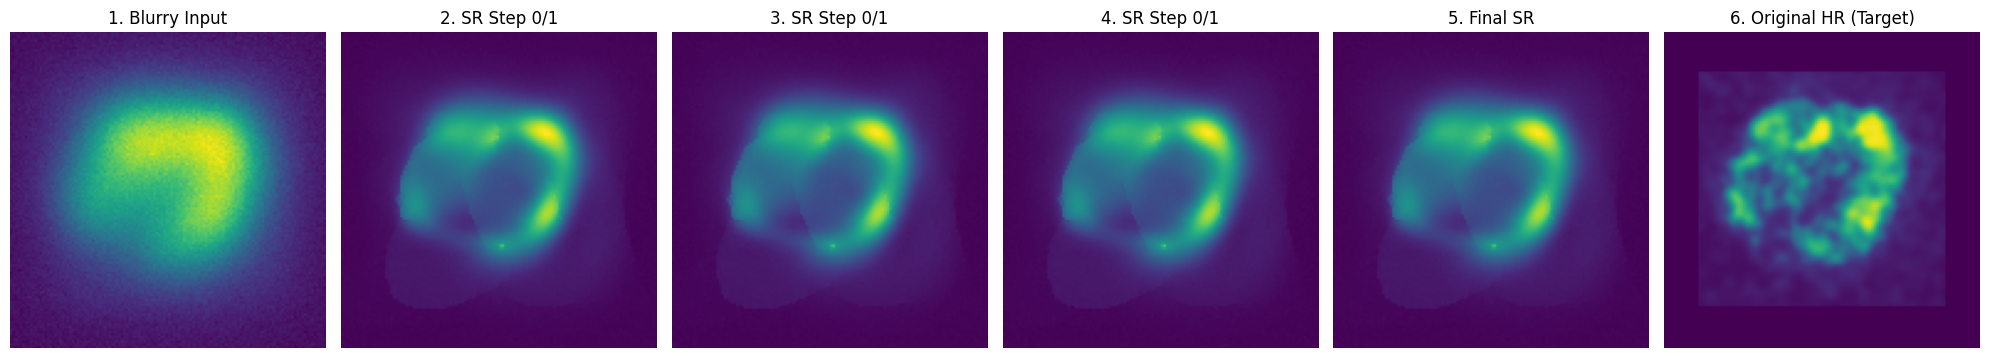

In [9]:
# ---- 3. 执行推理 ----
logger.info("正在生成并记录完整的扩散过程 (保存所有中间步)...")

with torch.no_grad():
    generated_images = diffusion.reverse_diffusion(
        model=unet,
        n_images=1,
        n_channels=1,
        input_image=test_input_images,
        # 常见用法 1: 传入 True (如果底层代码是 if save_time_steps:)
        # 常见用法 2: 传入 1 (如果底层代码是 if t % save_time_steps == 0:)
        # 这里建议先尝试传入 True 或者 1
        save_time_steps=2000
    )

# 打印一下实际生成的形状，确保它是一个长序列，比如 (1000, 1, 1, 128, 128)
print(f"生成的轨迹原始 Shape: {generated_images.shape}")

# 转置维度，(T, B, C, H, W) → (B, T, C, H, W)
generated_images = generated_images.swapaxes(0, 1)

# ---- 4. 提取中间步数据 ----
img_LR = test_input_images.cpu().squeeze().numpy()
img_HR = test_target_images.cpu().squeeze().numpy()

# 从实际返回的序列中动态获取总步数
total_steps = generated_images.shape[1] 

# 计算对应进度的索引
step_14 = total_steps // 4
step_12 = total_steps // 2
step_34 = 3 * total_steps // 4

# 现在 generated_images 包含所有步，直接按下标提取绝对安全
sr_14 = generated_images[0, step_14].cpu().squeeze().numpy()
sr_12 = generated_images[0, step_12].cpu().squeeze().numpy()
sr_34 = generated_images[0, step_34].cpu().squeeze().numpy()
sr_final = generated_images[0, -1].cpu().squeeze().numpy()

# 统一按各自的最大值归一化
eps = 1e-8
img_LR = img_LR / (img_LR.max() + eps)
img_HR = img_HR / (img_HR.max() + eps)
sr_14 = sr_14 / (sr_14.max() + eps)
sr_12 = sr_12 / (sr_12.max() + eps)
sr_34 = sr_34 / (sr_34.max() + eps)
sr_final = sr_final / (sr_final.max() + eps)

# ---- 5. 绘图展示 ----
fig, axes = plt.subplots(1, 6, figsize=(20, 3.5))

axes[0].imshow(img_LR, cmap='viridis')
axes[0].set_title('1. Blurry Input')
axes[0].axis('off')

axes[1].imshow(sr_14, cmap='viridis')
axes[1].set_title(f'2. SR Step {step_14}/{total_steps}')
axes[1].axis('off')

axes[2].imshow(sr_12, cmap='viridis')
axes[2].set_title(f'3. SR Step {step_12}/{total_steps}')
axes[2].axis('off')

axes[3].imshow(sr_34, cmap='viridis')
axes[3].set_title(f'4. SR Step {step_34}/{total_steps}')
axes[3].axis('off')

axes[4].imshow(sr_final, cmap='viridis')
axes[4].set_title('5. Final SR')
axes[4].axis('off')

axes[5].imshow(img_HR, cmap='viridis')
axes[5].set_title('6. Original HR (Target)')
axes[5].axis('off')

plt.tight_layout()